# Playing with dataset

In [13]:
import rootutils
root = rootutils.setup_root(".", indicator=".project-root", pythonpath=True)
%cd {root}
%pwd

/home/dgcnz/development/thesis/PART/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/dgcnz/development/thesis/PART


'/home/dgcnz/development/thesis/PART'

In [14]:
from PIL import Image
import itertools
import torch
import numpy as np
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import gradio as gr
from gradio_patch_selection import PatchSelector
import torchvision.transforms as T
from omegaconf import OmegaConf
import hydra
import logging
from torch.utils._pytree import tree_map_only

In [15]:
bg_size = (224, 224)
obj_size = (56, 56)
positions = [(0, 100), (100, 100)]


In [16]:
def overlay_img(bg_img, obj_img, pos):
    """
    Overlay an object image on a background image at a specified position.
    """
    new_img = bg_img.copy()
    new_img.paste(obj_img, pos, obj_img)
    return new_img.convert("RGB")  # Ensure the image is in RGB mode

In [17]:
landscape = Image.open("artifacts/landscape.webp").resize(bg_size)
dog = Image.open("artifacts/samoyed_nobg.png").resize(obj_size)

In [18]:
# Overlay the dog on the landscape
for pos in positions:
    new_img = overlay_img(landscape, dog, pos)
    new_img.save(f"artifacts/{pos[0]}_{pos[1]}.jpg")


In [19]:
# overlay dog at multiple po

In [20]:
X = list(range(0, 224, 56))
# Y = [100] * len(X)
Y = [112, 168]
positions = list(itertools.product(X, Y))
print(positions)
new_img = landscape.copy()
for pos in positions:
    new_img = overlay_img(new_img, dog, pos)

# new_img.save("../../artifacts/samoyed_all.jpg")
new_img.save("artifacts/bottom.jpg")

[(0, 112), (0, 168), (56, 112), (56, 168), (112, 112), (112, 168), (168, 112), (168, 168)]


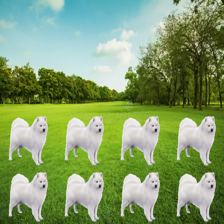

In [21]:
new_img

In [22]:
%load_ext gradio

The gradio extension is already loaded. To reload it, use:
  %reload_ext gradio


In [23]:
logging.basicConfig(level=logging.INFO)

# Configuration
PATCH_SIZE = 16  # must match model.patch_size
IMG_SIZE = 224  # must match model.img_size
DEVICE = "cpu"

# Preprocessing: convert to tensor, normalize with ImageNet stats
transform = T.Compose(
    [
        T.ToTensor(),
        T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ]
)


CFG_FOLDER = Path("fabric_configs/experiment/hummingbird/model")
MODELS = [
    "dino_b",
    "cim_b",
    "droppos_b",
    "partmae_v5_b",
    "partmae_v6_ep074_b",
    "partmae_v6_ep099_b",
    "partmae_v6_ep149_b",
    "partmae_v6_b", # 199
    "partmae_v6_b_noscale",
    "mae_b",
    "part_v0",
]
MODEL = "partmae_v6_b"

# Global model variable
model = None


def load_model(model_name: str):
    """Load a model from its configuration file."""
    global model
    logging.info(f"Loading model: {model_name}")
    assert model_name in MODELS, f"Model {model_name} not found in {MODELS}"
    model_conf = OmegaConf.load(CFG_FOLDER / f"{model_name}.yaml")
    model = (
        hydra.utils.instantiate({"model": model_conf}, _convert_="all")["model"]["net"]
        .eval()
        .to(DEVICE)
    )
    logging.info(f"Model {model_name} loaded.")
    return f"Model '{model_name}' loaded successfully."


# Load initial model
load_model(MODEL)

INFO:root:Loading model: partmae_v6_b


<class 'dict'>


INFO:timm.models._builder:Loading pretrained weights from state dict
INFO:root:Model partmae_v6_b loaded.


"Model 'partmae_v6_b' loaded successfully."